# Energy-aware Slice Placement – Data Analysis

This notebook analyzes the results obtained from the execution of the proposed
energy-aware MILP and heuristic algorithms for 5G slice placement.

The analysis focuses on:
- acceptance rate 
- total energy consumption,
- node activation and CPU utilization,
- routing characteristics,
- scalability and runtime behavior.

All results are generated from CSV files produced by the simulation pipeline.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = "./results/2026-06-15_08-36-03"

metrics = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
links = pd.read_csv(f"{RESULTS_DIR}/link_bw_load_all_methods.csv")
routes = pd.read_csv(f"{RESULTS_DIR}/routes_all_methods.csv")
nodes = pd.read_csv(f"{RESULTS_DIR}/node_cpu_load_all_methods.csv")
slices_info = pd.read_csv(f"{RESULTS_DIR}/slice_entries.csv")

for df in [metrics, links, routes, nodes, slices_info]:
    df.columns = [c.strip().lower() for c in df.columns]

metrics.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841


/tmp/ipykernel_2774092/1151788193.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


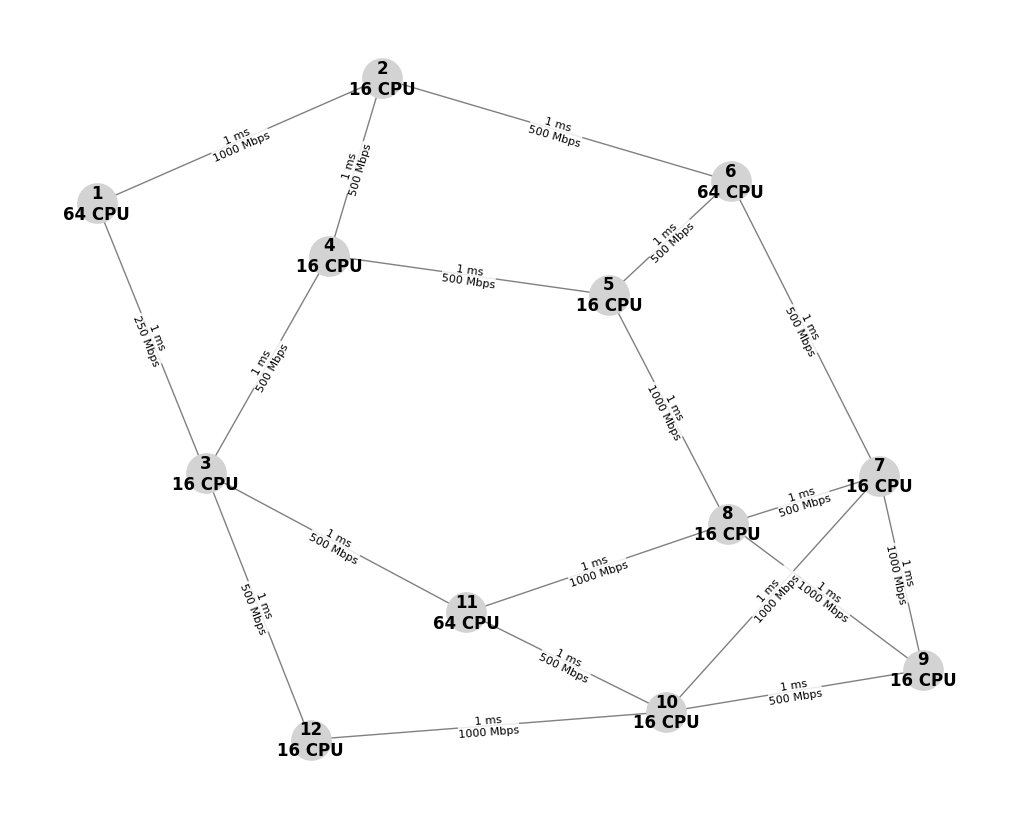

In [23]:
import matplotlib.pyplot as plt
import networkx as nx

from utils.topology import topologie_finlande


def draw_graph(G):
    pos = nx.spring_layout(G, seed=42)

    node_labels = {
        node: f"{node}\n{G.nodes[node]['cpu']} CPU"
        for node in G.nodes
    }

    plt.figure(figsize=(10, 8))

    nx.draw(
        G,
        pos,
        labels=node_labels,
        node_color="lightgray",
        node_size=800,
        edge_color="gray",
        font_weight="bold",
        with_labels=True,
        arrows=False,
    )

    edge_labels = {
        (u, v): (
            f"{G[u][v].get('weight', G[u][v].get('latency'))} ms\n"
            f"{G[u][v]['bandwidth']} Mbps"
        )
        for u, v in G.edges
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_color="black",
        font_size=8,
        rotate=True,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=0.15,
        ),
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


G = topologie_finlande()
draw_graph(G)

In [3]:
metrics["acceptance_rate"] = metrics["accepted"] / metrics["num_slices"]
metrics["energy_per_accepted_slice"] = metrics["total_energy"] / metrics["accepted"]
metrics["latency_per_accepted_slice"] = metrics["total_latency"] / metrics["accepted"]
metrics["bandwidth_per_accepted_slice"] = metrics["total_bandwidth"] / metrics["accepted"]
metrics["qos_efficiency"] = metrics["accepted"] / metrics["total_energy"]

metrics = metrics.replace([np.inf, -np.inf], np.nan)

metrics.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate,energy_per_accepted_slice,latency_per_accepted_slice,bandwidth_per_accepted_slice,qos_efficiency
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240,1.0,3.574688,1.0,47.5,0.279745
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377,1.0,3.594375,1.0,47.5,0.278212
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956,1.0,4.047187,1.5,70.0,0.247085
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561,1.0,2.782500,1.0,47.5,0.359389
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841,1.0,1.977188,1.0,47.5,0.505769


In [4]:
metrics_agg = (
    metrics
    .groupby(["method", "num_slices", "num_vnfs_per_slice"], as_index=False)
    .agg(
        mean_acceptance_rate=("acceptance_rate", "mean"),
        std_acceptance_rate=("acceptance_rate", "std"),
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
        mean_qos_efficiency=("qos_efficiency", "mean"),
        std_qos_efficiency=("qos_efficiency", "std"),
        mean_latency_per_slice=("latency_per_accepted_slice", "mean"),
        std_latency_per_slice=("latency_per_accepted_slice", "std"),
        mean_bandwidth_per_slice=("bandwidth_per_accepted_slice", "mean"),
        std_bandwidth_per_slice=("bandwidth_per_accepted_slice", "std"),
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
    )
)

metrics_agg.head()

,method,num_slices,num_vnfs_per_slice,mean_acceptance_rate,std_acceptance_rate,mean_energy,std_energy,mean_qos_efficiency,std_qos_efficiency,mean_latency_per_slice,std_latency_per_slice,mean_bandwidth_per_slice,std_bandwidth_per_slice,mean_runtime,std_runtime
0,A*,2,2,1.0,0.0,7.028125,0.548499,0.286093,0.024396,1.0,0.0,47.5,0.0,0.007309,0.001858
1,A*,2,3,1.0,0.0,11.050875,1.443416,0.184026,0.029139,2.0,0.0,100.0,0.0,0.009550,0.000768
2,A*,2,4,1.0,0.0,15.830625,1.020807,0.126783,0.008654,3.0,0.0,155.0,0.0,0.011845,0.000656
3,A*,2,5,1.0,0.0,20.281750,0.594122,0.098681,0.003004,4.0,0.0,212.5,0.0,0.015648,0.000686
4,A*,2,6,1.0,0.0,21.595500,0.803335,0.092715,0.003467,5.0,0.0,167.5,0.0,0.016714,0.001532


In [5]:
link_qos = (
    links
    .groupby(["method", "num_slices", "num_vnfs_per_slice", "seed"], as_index=False)
    .agg(
        mean_link_utilization=("bw_utilization", "mean"),
        max_link_utilization=("bw_utilization", "max"),
        std_link_utilization=("bw_utilization", "std"),
    )
)

qos_full = metrics.merge(
    link_qos,
    on=["method", "num_slices", "num_vnfs_per_slice", "seed"],
    how="left",
)

qos_full.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate,energy_per_accepted_slice,latency_per_accepted_slice,bandwidth_per_accepted_slice,qos_efficiency,mean_link_utilization,max_link_utilization,std_link_utilization
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240,1.0,3.574688,1.0,47.5,0.279745,0.145000,0.200,0.077782
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377,1.0,3.594375,1.0,47.5,0.278212,0.047500,0.050,0.003536
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956,1.0,4.047187,1.5,70.0,0.247085,0.078333,0.100,0.029297
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561,1.0,2.782500,1.0,47.5,0.359389,0.095000,0.100,0.007071
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841,1.0,1.977188,1.0,47.5,0.505769,0.095000,0.095,NaN


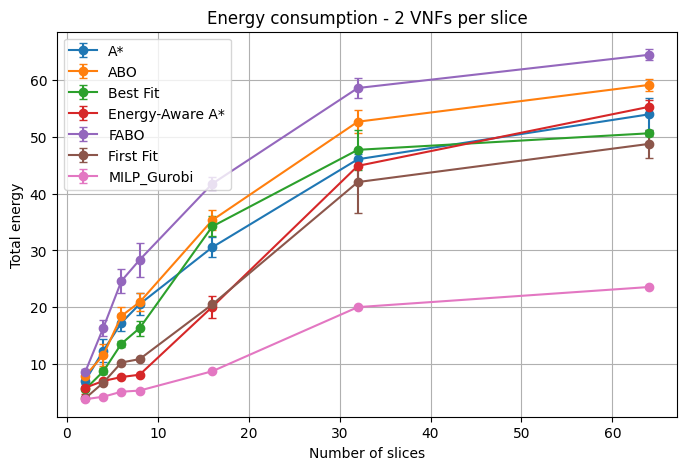

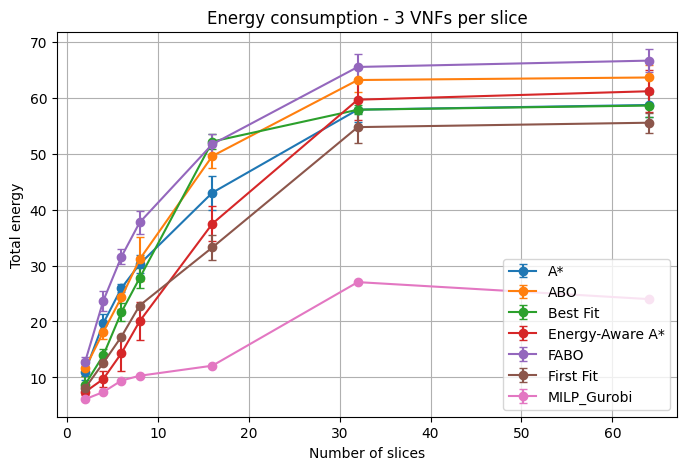

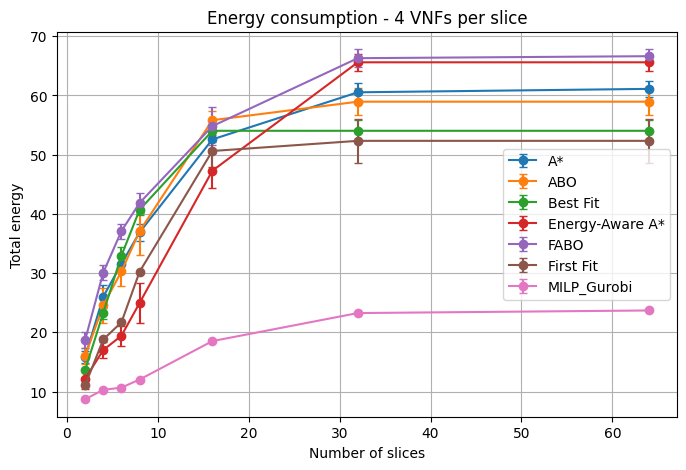

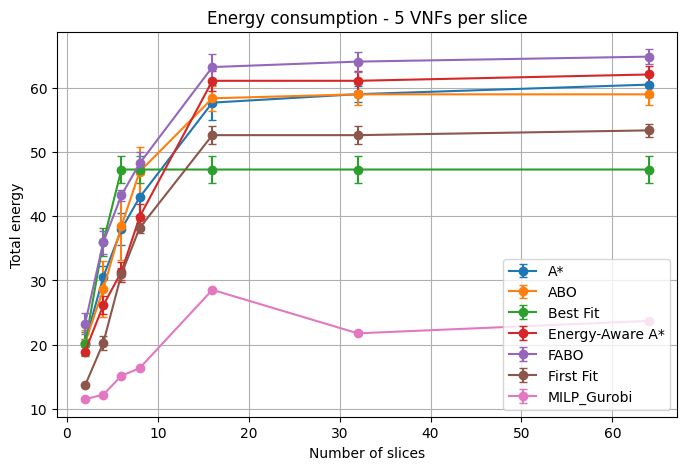

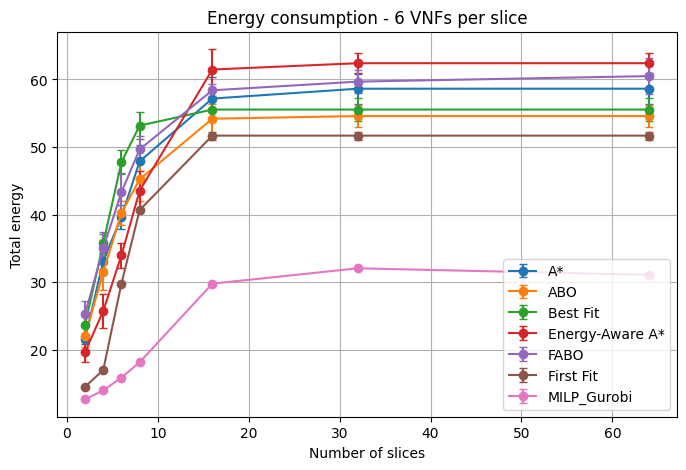

In [6]:
for vnf in sorted(metrics_agg["num_vnfs_per_slice"].unique()):
    sub = metrics_agg[metrics_agg["num_vnfs_per_slice"] == vnf]

    plt.figure(figsize=(8, 5))

    for method in sorted(sub["method"].unique()):
        m = sub[sub["method"] == method]
        plt.errorbar(
            m["num_slices"],
            m["mean_energy"],
            yerr=m["std_energy"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(f"Energy consumption - {vnf} VNFs per slice")
    plt.xlabel("Number of slices")
    plt.ylabel("Total energy")
    plt.grid(True)
    plt.legend()
    plt.show()

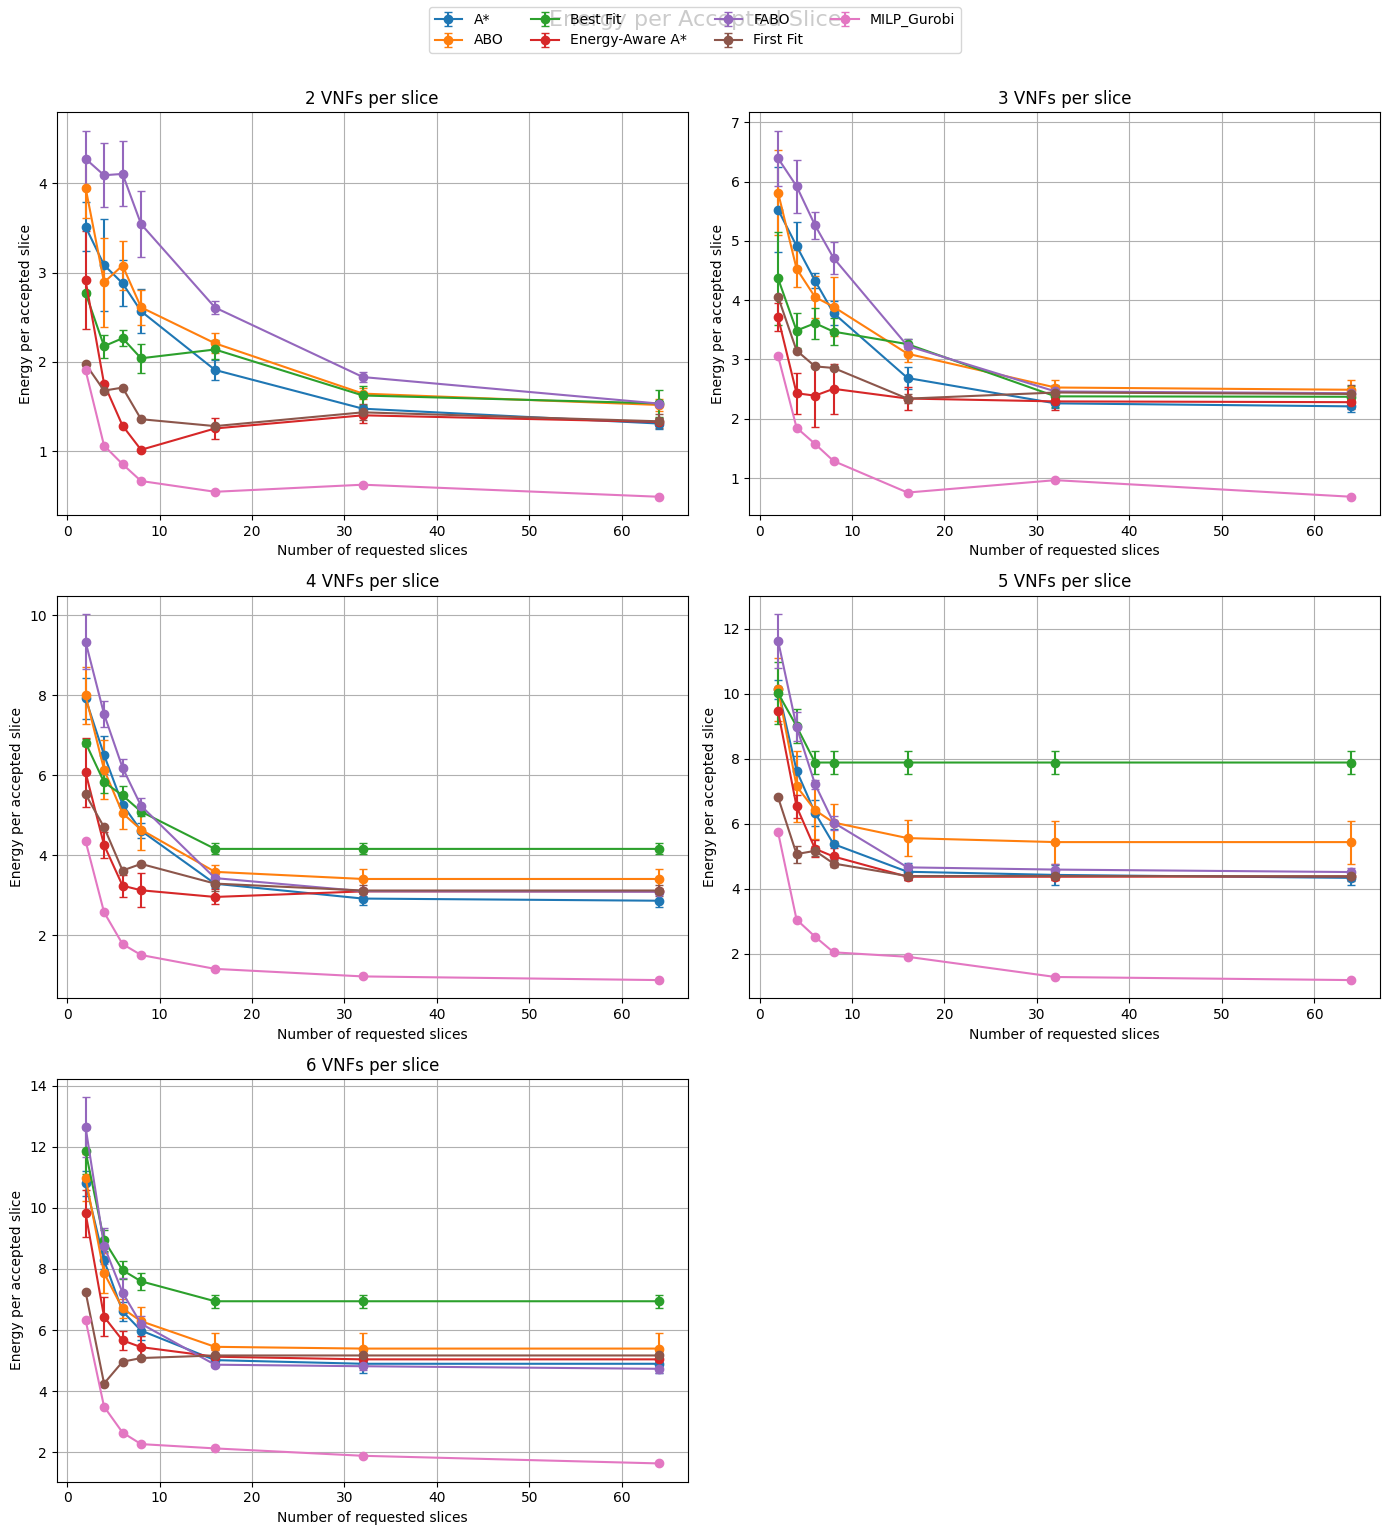

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

metrics = metrics.copy()

metrics["energy_per_accepted_slice"] = (
    metrics["total_energy"] / metrics["accepted"]
)

metrics["energy_per_accepted_slice"] = metrics["energy_per_accepted_slice"].replace(
    [np.inf, -np.inf],
    np.nan,
)

energy_per_slice_agg = (
    metrics
    .dropna(subset=["energy_per_accepted_slice"])
    .groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_energy_per_accepted_slice=("energy_per_accepted_slice", "mean"),
        std_energy_per_accepted_slice=("energy_per_accepted_slice", "std"),
        num_runs=("energy_per_accepted_slice", "count"),
    )
)

# --------------------------------------------------
# Single figure with one subplot per VNF count
# --------------------------------------------------

vnfs = sorted(
    energy_per_slice_agg["num_vnfs_per_slice"].unique()
)

ncols = 2
nrows = math.ceil(len(vnfs) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 5 * nrows),
)

axes = np.array(axes).flatten()

for ax, vnf in zip(axes, vnfs):

    sub = energy_per_slice_agg[
        energy_per_slice_agg["num_vnfs_per_slice"] == vnf
    ]

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        ax.errorbar(
            m["num_slices"],
            m["mean_energy_per_accepted_slice"],
            yerr=m["std_energy_per_accepted_slice"],
            marker="o",
            capsize=3,
            label=method,
        )

    ax.set_title(f"{vnf} VNFs per slice")
    ax.set_xlabel("Number of requested slices")
    ax.set_ylabel("Energy per accepted slice")
    ax.grid(True)

# Hide unused subplots
for ax in axes[len(vnfs):]:
    ax.axis("off")

# Global legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
)

fig.suptitle(
    "Energy per Accepted Slice",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "energy_per_accepted_slice_all.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [9]:
import pandas as pd

df = metrics.copy()
df.columns = [c.strip().lower() for c in df.columns]

df["acceptance_rate"] = 100 * df["accepted"] / df["num_slices"]

summary_tables = {}

for vnf in sorted(df["num_vnfs_per_slice"].unique()):
    sub = df[df["num_vnfs_per_slice"] == vnf].copy()

    table = (
        sub.groupby("method", as_index=False)
        .agg(
            acceptance_mean=("acceptance_rate", "mean"),
            acceptance_std=("acceptance_rate", "std"),
            energy_mean=("total_energy", "mean"),
            energy_std=("total_energy", "std"),
            runtime_mean=("runtime_sec", "mean"),
            runtime_std=("runtime_sec", "std"),
        )
    )

    table["Acceptance"] = table.apply(
        lambda r: f"{r['acceptance_mean']:.1f} ± {r['acceptance_std']:.1f}", axis=1
    )
    table["Energy"] = table.apply(
        lambda r: f"{r['energy_mean']:.3f} ± {r['energy_std']:.3f}", axis=1
    )
    table["Runtime"] = table.apply(
        lambda r: f"{r['runtime_mean']:.4f} ± {r['runtime_std']:.4f}", axis=1
    )

    table = table.rename(columns={"method": "Método"})
    table = table[["Método", "Acceptance", "Energy", "Runtime"]]

    summary_tables[vnf] = table

    print(f"\n=== {vnf} VNFs per slice ===")
    display(table)


=== 2 VNFs per slice ===


,Método,Acceptance,Energy,Runtime
0,A*,94.6 ± 12.6,26.826 ± 16.584,0.0260 ± 0.0177
1,ABO,94.4 ± 13.9,29.427 ± 18.967,0.0053 ± 0.0040
2,Best Fit,92.0 ± 17.1,25.250 ± 17.660,0.0234 ± 0.0137
3,Energy-Aware A*,95.0 ± 12.4,21.279 ± 19.268,0.0053 ± 0.0042
4,FABO,95.1 ± 12.2,34.669 ± 19.865,0.0102 ± 0.0082
5,First Fit,92.6 ± 15.3,20.447 ± 16.942,0.0044 ± 0.0041
6,MILP_Gurobi,96.4 ± 8.9,10.125 ± 7.695,639.8096 ± 803.9346



=== 3 VNFs per slice ===


,Método,Acceptance,Energy,Runtime
0,A*,88.8 ± 20.8,35.204 ± 17.487,0.0341 ± 0.0198
1,ABO,88.3 ± 21.4,37.346 ± 20.187,0.0069 ± 0.0050
2,Best Fit,87.9 ± 22.1,34.376 ± 20.087,0.0286 ± 0.0159
3,Energy-Aware A*,89.0 ± 20.6,29.960 ± 21.744,0.0083 ± 0.0060
4,FABO,89.4 ± 20.2,41.347 ± 19.479,0.0222 ± 0.0161
5,First Fit,85.0 ± 22.9,29.187 ± 18.285,0.0077 ± 0.0083
6,MILP_Gurobi,91.7 ± 16.0,13.774 ± 7.794,518.3869 ± 823.4107



=== 4 VNFs per slice ===


,Método,Acceptance,Energy,Runtime
0,A*,85.5 ± 24.8,40.642 ± 16.690,0.0497 ± 0.0453
1,ABO,82.7 ± 28.0,40.226 ± 16.812,0.0094 ± 0.0072
2,Best Fit,77.5 ± 31.3,38.949 ± 15.427,0.0343 ± 0.0196
3,Energy-Aware A*,85.6 ± 24.8,35.999 ± 21.794,0.0124 ± 0.0081
4,FABO,85.8 ± 24.5,45.061 ± 17.245,0.0495 ± 0.0510
5,First Fit,82.1 ± 28.4,33.862 ± 16.714,0.0098 ± 0.0109
6,MILP_Gurobi,88.2 ± 21.0,15.306 ± 5.999,631.7110 ± 791.7804



=== 5 VNFs per slice ===


,Método,Acceptance,Energy,Runtime
0,A*,77.7 ± 30.7,44.160 ± 14.842,0.0427 ± 0.0192
1,ABO,73.6 ± 33.3,44.400 ± 15.134,0.0100 ± 0.0070
2,Best Fit,62.9 ± 37.8,41.790 ± 10.018,0.0405 ± 0.0270
3,Energy-Aware A*,79.1 ± 30.5,42.959 ± 17.345,0.0184 ± 0.0105
4,FABO,78.8 ± 30.3,49.011 ± 15.174,0.0968 ± 0.0672
5,First Fit,75.9 ± 32.2,37.397 ± 15.477,0.0107 ± 0.0117
6,MILP_Gurobi,82.6 ± 26.7,18.439 ± 5.984,799.1095 ± 884.0141



=== 6 VNFs per slice ===


,Método,Acceptance,Energy,Runtime
0,A*,75.4 ± 32.3,45.245 ± 13.663,0.0503 ± 0.0241
1,ABO,71.5 ± 33.4,43.183 ± 12.170,0.0119 ± 0.0087
2,Best Fit,67.9 ± 35.8,46.719 ± 11.774,0.0436 ± 0.0233
3,Energy-Aware A*,76.2 ± 31.9,44.171 ± 17.307,0.0320 ± 0.0206
4,FABO,76.2 ± 31.7,47.410 ± 12.911,0.1954 ± 0.1520
5,First Fit,72.8 ± 34.4,36.720 ± 15.429,0.0114 ± 0.0112
6,MILP_Gurobi,81.5 ± 26.8,21.937 ± 8.115,1076.5977 ± 856.5946


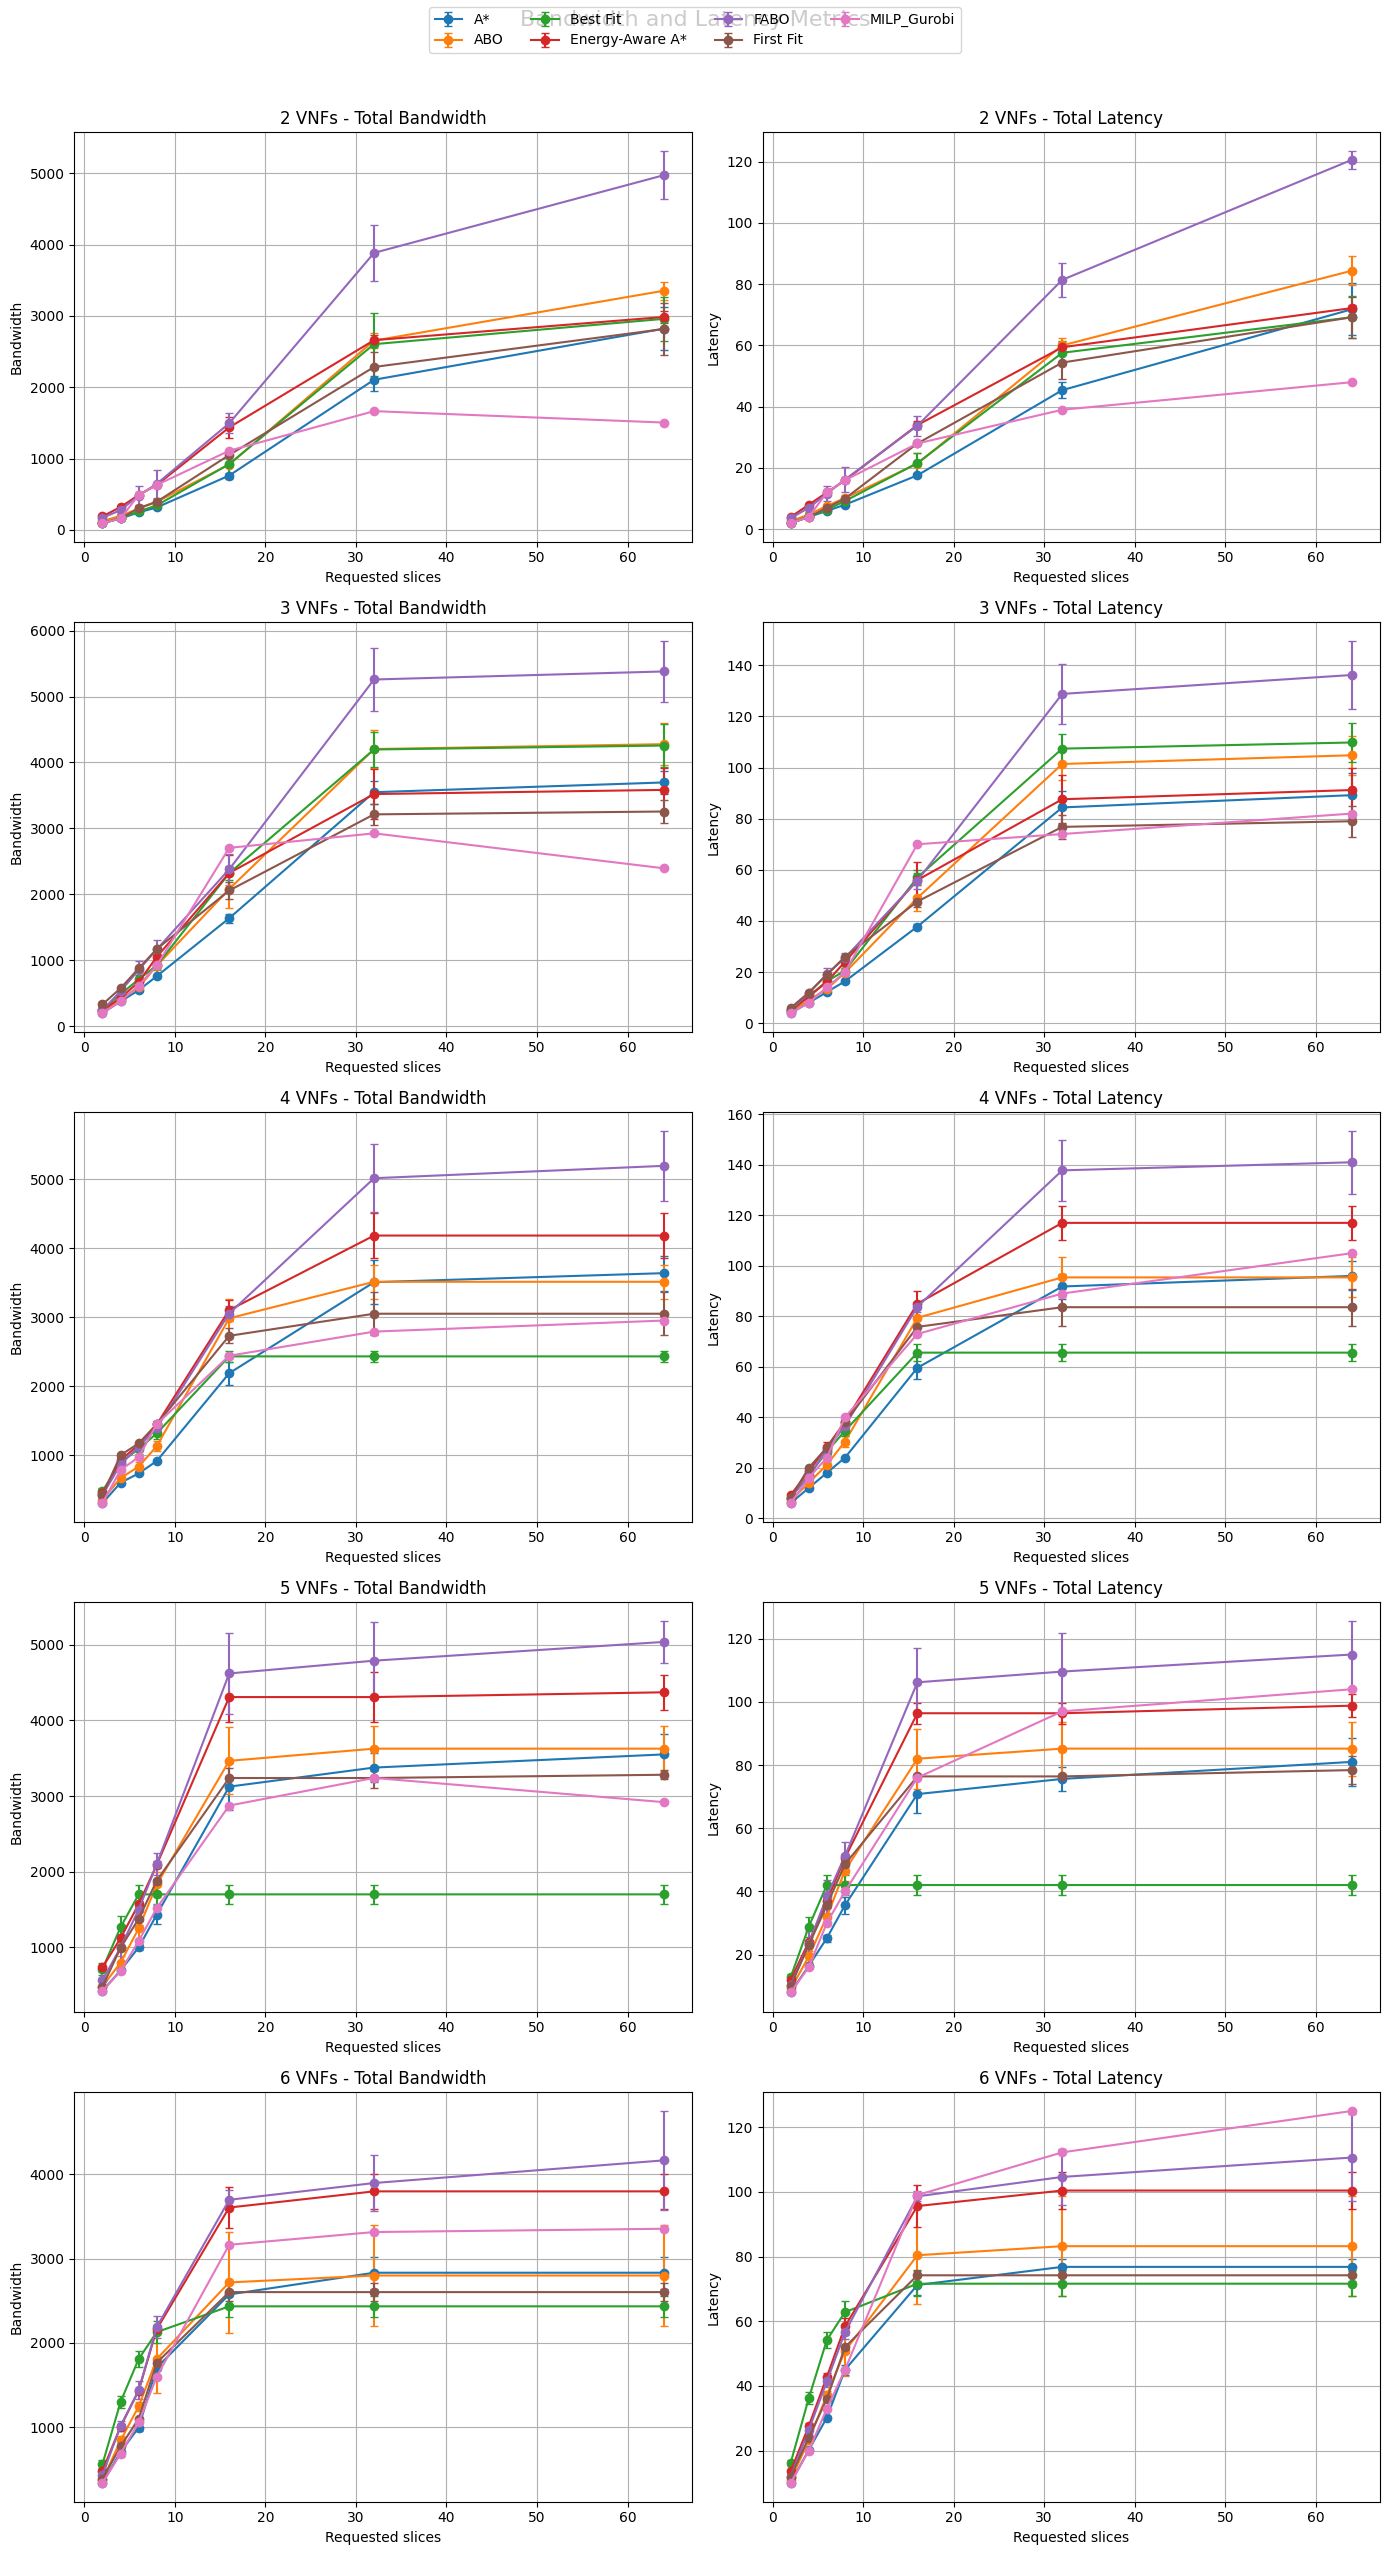

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Load results
# -------------------------------------------------------

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

# -------------------------------------------------------
# Aggregate
# -------------------------------------------------------

metrics_agg = (
    df.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False,
    )
    .agg(
        mean_bw=("total_bandwidth", "mean"),
        std_bw=("total_bandwidth", "std"),
        mean_latency=("total_latency", "mean"),
        std_latency=("total_latency", "std"),
    )
)

vnfs = sorted(metrics_agg["num_vnfs_per_slice"].unique())

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

fig, axes = plt.subplots(
    len(vnfs),
    2,
    figsize=(14, 5 * len(vnfs)),
)

if len(vnfs) == 1:
    axes = np.array([axes])

for row, vnf in enumerate(vnfs):

    sub = metrics_agg[
        metrics_agg["num_vnfs_per_slice"] == vnf
    ]

    ax_bw = axes[row, 0]
    ax_lat = axes[row, 1]

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        # -------------------------
        # Bandwidth
        # -------------------------

        ax_bw.errorbar(
            m["num_slices"],
            m["mean_bw"],
            yerr=m["std_bw"],
            marker="o",
            capsize=3,
            label=method,
        )

        # -------------------------
        # Latency
        # -------------------------

        ax_lat.errorbar(
            m["num_slices"],
            m["mean_latency"],
            yerr=m["std_latency"],
            marker="o",
            capsize=3,
            label=method,
        )

    ax_bw.set_title(f"{vnf} VNFs - Total Bandwidth")
    ax_bw.set_xlabel("Requested slices")
    ax_bw.set_ylabel("Bandwidth")
    ax_bw.grid(True)

    ax_lat.set_title(f"{vnf} VNFs - Total Latency")
    ax_lat.set_xlabel("Requested slices")
    ax_lat.set_ylabel("Latency")
    ax_lat.grid(True)

# Shared legend

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
)

fig.suptitle(
    "Bandwidth and Latency Metrics",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "bandwidth_latency_metrics.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [11]:
import pandas as pd

metrics = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
metrics.columns = [c.strip().lower() for c in metrics.columns]

metrics["avg_latency_per_slice"] = (
    metrics["total_latency"] / metrics["accepted"]
)

metrics = metrics.replace([float("inf"), -float("inf")], pd.NA)

for vnf in sorted(metrics["num_vnfs_per_slice"].unique()):

    table = (
        metrics[
            metrics["num_vnfs_per_slice"] == vnf
        ]
        .groupby("method")
        .agg(
            Mean=("avg_latency_per_slice","mean"),
            Std=("avg_latency_per_slice","std"),
        )
        .round(3)
    )

    print(f"\n===== {vnf} VNFs per slice =====")
    display(table)


===== 2 VNFs per slice =====


,Mean,Std
method,,
A*,1.185,0.283
ABO,1.488,0.379
Best Fit,1.381,0.446
Energy-Aware A*,1.960,0.123
FABO,2.148,0.481
First Fit,1.417,0.380
MILP_Gurobi,1.424,0.446



===== 3 VNFs per slice =====


,Mean,Std
method,,
A*,2.441,0.585
ABO,2.925,0.823
Best Fit,3.251,0.853
Energy-Aware A*,3.010,0.467
FABO,3.605,0.918
First Fit,3.233,0.189
MILP_Gurobi,2.599,0.769



===== 4 VNFs per slice =====


,Mean,Std
method,,
A*,3.519,0.669
ABO,4.343,0.945
Best Fit,4.602,0.465
Energy-Aware A*,5.010,0.461
FABO,5.086,1.024
First Fit,4.755,0.345
MILP_Gurobi,4.023,0.595



===== 5 VNFs per slice =====


,Mean,Std
method,,
A*,4.816,0.785
ABO,6.285,1.469
Best Fit,6.943,0.571
Energy-Aware A*,6.460,0.432
FABO,6.777,1.220
First Fit,5.988,0.480
MILP_Gurobi,4.853,0.593



===== 6 VNFs per slice =====


,Mean,Std
method,,
A*,5.684,0.666
ABO,6.951,1.227
Best Fit,8.858,0.530
Energy-Aware A*,7.471,0.590
FABO,7.405,1.000
First Fit,6.680,0.679
MILP_Gurobi,5.911,0.784


In [15]:
links = pd.read_csv(f"{RESULTS_DIR}/link_bw_load_all_methods.csv")
links.columns = [c.strip().lower() for c in links.columns]

links["utilization"] = (
    links["bw_used"] /
    links["bw_capacity"]
)

for vnf in sorted(links["num_vnfs_per_slice"].unique()):

    table = (
        links[
            links["num_vnfs_per_slice"] == vnf
        ]
        .groupby("method")
        .agg(
            Mean=("utilization","mean"),
            Std=("utilization","std"),
            Maximum=("utilization","max"),
        )
        .round(3)
    )

    print(f"\n===== {vnf} VNFs per slice =====")
    display(table)


===== 2 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,0.162,0.146,0.88
ABO,0.126,0.104,0.59
Best Fit,0.174,0.157,0.75
Energy-Aware A*,0.188,0.172,0.84
FABO,0.141,0.111,0.55
First Fit,0.220,0.161,0.71
MILP_Gurobi,0.200,0.161,0.62



===== 3 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,0.177,0.164,0.96
ABO,0.144,0.108,0.54
Best Fit,0.200,0.174,0.85
Energy-Aware A*,0.182,0.153,0.74
FABO,0.162,0.123,0.61
First Fit,0.224,0.188,0.76
MILP_Gurobi,0.219,0.144,0.60



===== 4 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,0.161,0.164,1.00
ABO,0.126,0.079,0.44
Best Fit,0.150,0.129,0.80
Energy-Aware A*,0.206,0.192,0.98
FABO,0.155,0.114,0.53
First Fit,0.210,0.163,0.63
MILP_Gurobi,0.203,0.151,0.72



===== 5 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,0.165,0.158,1.00
ABO,0.133,0.094,0.58
Best Fit,0.113,0.092,0.47
Energy-Aware A*,0.193,0.134,0.62
FABO,0.160,0.114,0.58
First Fit,0.213,0.152,0.82
MILP_Gurobi,0.189,0.144,0.65



===== 6 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,0.135,0.134,0.80
ABO,0.112,0.084,0.52
Best Fit,0.128,0.091,0.54
Energy-Aware A*,0.173,0.139,0.82
FABO,0.135,0.087,0.50
First Fit,0.169,0.137,0.57
MILP_Gurobi,0.179,0.127,0.62


In [16]:
metrics = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
metrics.columns = [c.strip().lower() for c in metrics.columns]

for vnf in sorted(metrics["num_vnfs_per_slice"].unique()):

    table = (
        metrics[
            metrics["num_vnfs_per_slice"] == vnf
        ]
        .groupby("method")
        .agg(
            Mean=("total_latency","mean"),
            Maximum=("total_latency","max"),
        )
        .round(3)
    )

    print(f"\n===== {vnf} VNFs per slice =====")
    display(table)


===== 2 VNFs per slice =====


,Mean,Maximum
method,,
A*,22.114,78.0
ABO,27.286,90.0
Best Fit,24.314,77.0
Energy-Aware A*,29.371,73.0
FABO,39.171,125.0
First Fit,24.943,77.0
MILP_Gurobi,21.286,48.0



===== 3 VNFs per slice =====


,Mean,Maximum
method,,
A*,36.000,97.0
ABO,43.143,115.0
Best Fit,46.657,122.0
Energy-Aware A*,41.486,101.0
FABO,54.657,150.0
First Fit,38.057,88.0
MILP_Gurobi,38.857,82.0



===== 4 VNFs per slice =====


,Mean,Maximum
method,,
A*,43.914,100.0
ABO,48.971,104.0
Best Fit,40.429,70.0
Energy-Aware A*,59.029,127.0
FABO,64.486,152.0
First Fit,48.143,91.0
MILP_Gurobi,50.429,105.0



===== 5 VNFs per slice =====


,Mean,Maximum
method,,
A*,44.657,90.0
ABO,51.343,97.0
Best Fit,35.943,47.0
Energy-Aware A*,59.314,104.0
FABO,64.886,130.0
First Fit,49.771,86.0
MILP_Gurobi,53.000,104.0



===== 6 VNFs per slice =====


,Mean,Maximum
method,,
A*,47.171,80.0
ABO,52.686,104.0
Best Fit,54.886,77.0
Energy-Aware A*,62.686,109.0
FABO,64.314,130.0
First Fit,49.514,77.0
MILP_Gurobi,63.457,125.0


In [17]:
import pandas as pd
import numpy as np

metrics = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
metrics.columns = [c.strip().lower() for c in metrics.columns]

# ----------------------------------------
# Bandwidth per accepted slice
# ----------------------------------------

metrics["bw_per_accepted_slice"] = (
    metrics["total_bandwidth"] / metrics["accepted"]
)

metrics = metrics.replace(
    [np.inf, -np.inf],
    np.nan,
)

metrics = metrics.dropna(
    subset=["bw_per_accepted_slice"]
)

for vnf in sorted(metrics["num_vnfs_per_slice"].unique()):

    table = (
        metrics[
            metrics["num_vnfs_per_slice"] == vnf
        ]
        .groupby("method")
        .agg(
            Mean=("bw_per_accepted_slice", "mean"),
            Std=("bw_per_accepted_slice", "std"),
            Maximum=("bw_per_accepted_slice", "max"),
        )
        .round(3)
        .sort_values("Mean")
    )

    print(f"\n===== {vnf} VNFs per slice =====")
    display(table)


===== 2 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,50.160,12.030,75.976
MILP_Gurobi,57.240,18.375,81.667
First Fit,58.363,14.589,87.500
Best Fit,58.714,21.085,105.357
ABO,62.397,16.612,90.513
Energy-Aware A*,82.873,7.823,103.438
FABO,92.614,23.603,132.656



===== 3 VNFs per slice =====


,Mean,Std,Maximum
method,,,
MILP_Gurobi,107.601,28.831,169.062
A*,108.513,20.270,146.111
Energy-Aware A*,126.343,15.909,161.250
ABO,127.682,29.793,183.542
Best Fit,138.484,26.544,178.600
First Fit,147.250,7.804,165.000
FABO,154.790,31.658,215.185



===== 4 VNFs per slice =====


,Mean,Std,Maximum
method,,,
A*,145.878,21.997,193.333
MILP_Gurobi,153.656,30.043,197.500
ABO,175.125,28.818,220.667
Best Fit,196.409,28.105,270.000
First Fit,197.445,25.652,251.250
Energy-Aware A*,203.692,22.534,267.500
FABO,208.427,29.552,255.682



===== 5 VNFs per slice =====


,Mean,Std,Maximum
method,,,
MILP_Gurobi,183.263,19.415,212.500
A*,211.717,37.235,264.000
First Fit,251.853,18.009,282.083
ABO,269.178,69.317,403.500
FABO,296.556,52.925,367.857
Best Fit,298.821,36.055,410.000
Energy-Aware A*,299.343,37.197,367.500



===== 6 VNFs per slice =====


,Mean,Std,Maximum
method,,,
MILP_Gurobi,187.470,19.633,226.071
A*,202.991,30.993,247.500
First Fit,224.265,34.057,278.500
ABO,238.464,45.406,342.727
Energy-Aware A*,273.642,30.196,318.846
FABO,275.657,41.906,364.643
Best Fit,303.286,19.974,340.000


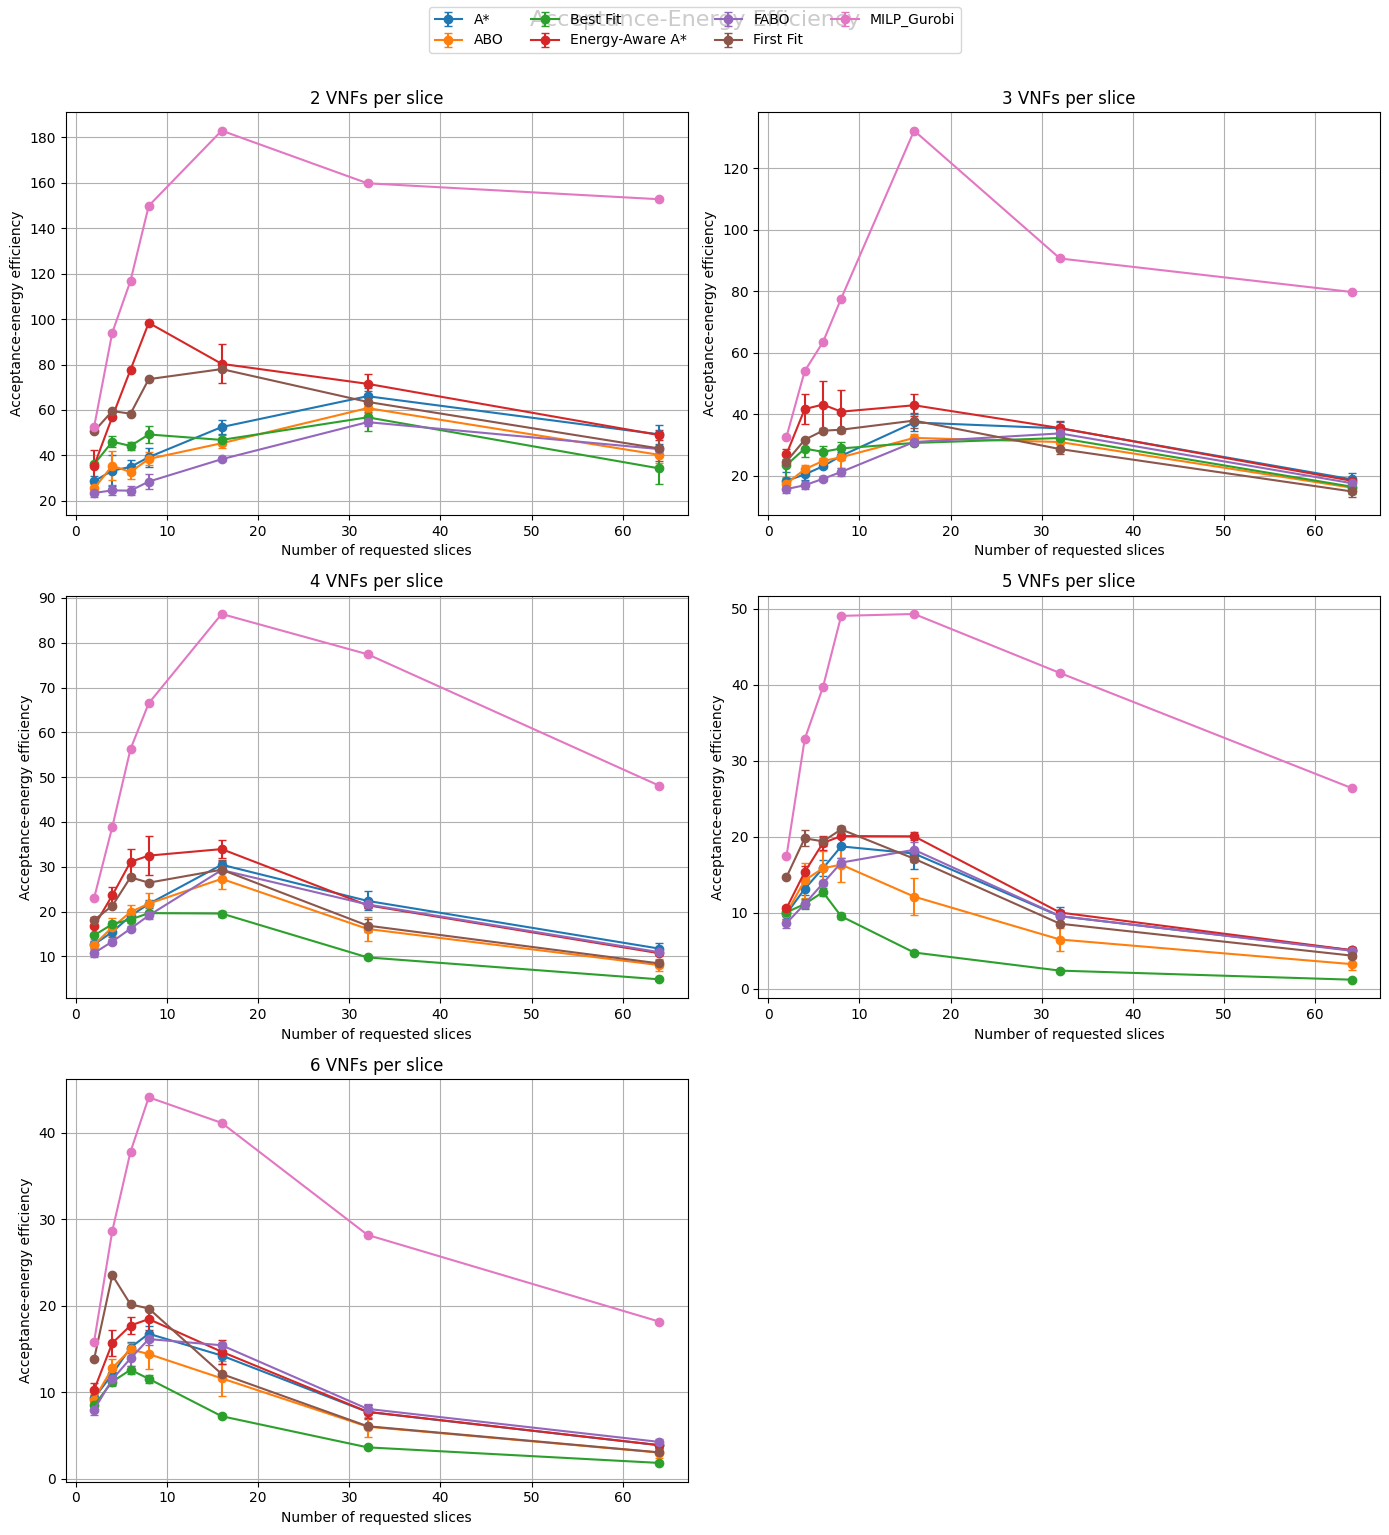

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

# Basic metrics
df["acceptance_rate"] = 100 * df["accepted"] / df["num_slices"]
df["energy_per_accepted_slice"] = df["total_energy"] / df["accepted"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["acceptance_rate", "energy_per_accepted_slice"])

# Composite metric:
# high acceptance + low energy per accepted slice = better
df["acceptance_energy_efficiency"] = (
    df["acceptance_rate"] / df["energy_per_accepted_slice"]
)

eff_agg = (
    df.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_efficiency=("acceptance_energy_efficiency", "mean"),
        std_efficiency=("acceptance_energy_efficiency", "std"),
        mean_acceptance=("acceptance_rate", "mean"),
        mean_energy_per_slice=("energy_per_accepted_slice", "mean"),
    )
)

vnfs = sorted(eff_agg["num_vnfs_per_slice"].unique())

ncols = 2
nrows = math.ceil(len(vnfs) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).flatten()

for ax, vnf in zip(axes, vnfs):
    sub = eff_agg[eff_agg["num_vnfs_per_slice"] == vnf]

    for method in sorted(sub["method"].unique()):
        m = sub[sub["method"] == method]

        ax.errorbar(
            m["num_slices"],
            m["mean_efficiency"],
            yerr=m["std_efficiency"],
            marker="o",
            capsize=3,
            label=method,
        )

    ax.set_title(f"{vnf} VNFs per slice")
    ax.set_xlabel("Number of requested slices")
    ax.set_ylabel("Acceptance-energy efficiency")
    ax.grid(True)

for ax in axes[len(vnfs):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)

fig.suptitle(
    "Acceptance-Energy Efficiency",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "acceptance_energy_efficiency.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

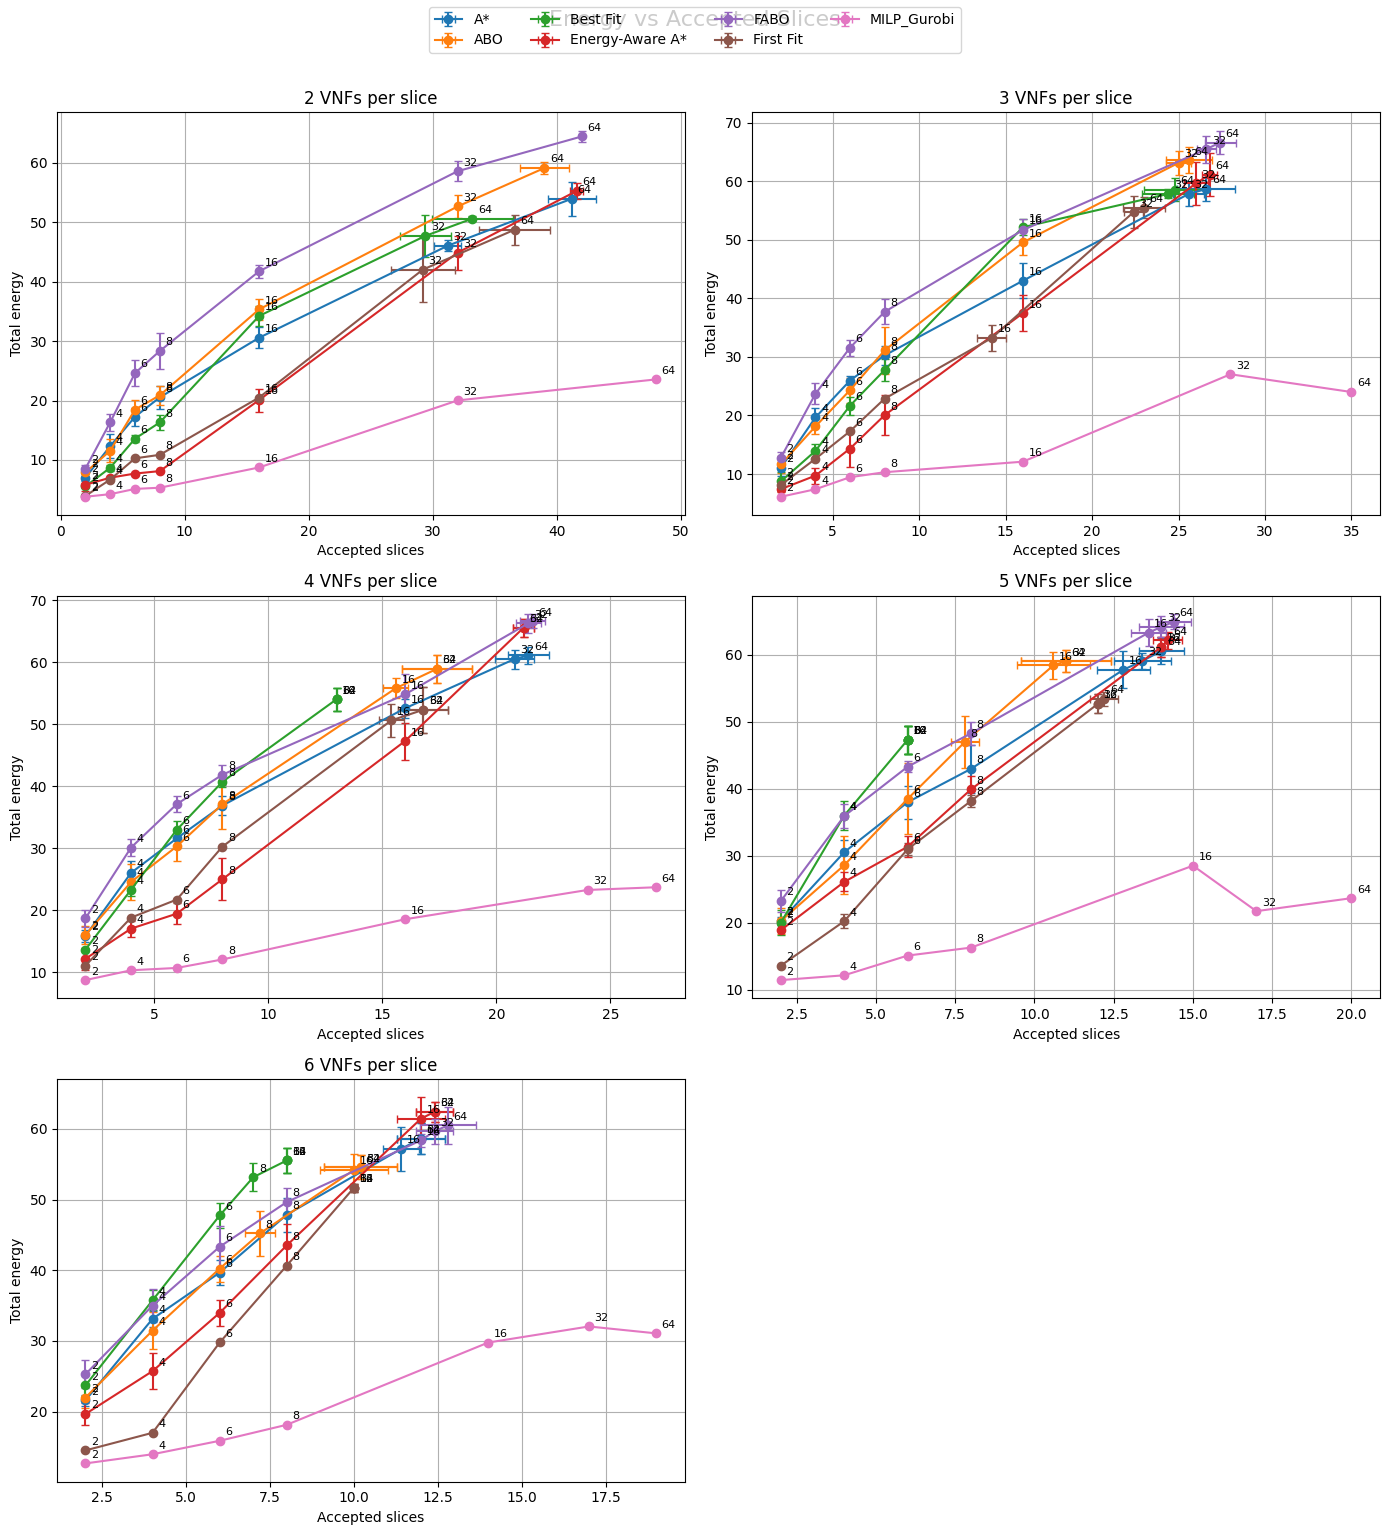

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

# Aggregate over seeds
tradeoff = (
    df.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_accepted=("accepted", "mean"),
        std_accepted=("accepted", "std"),
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
    )
)

vnfs = sorted(tradeoff["num_vnfs_per_slice"].unique())

ncols = 2
nrows = math.ceil(len(vnfs) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 5 * nrows)
)

axes = np.array(axes).flatten()

for ax, vnf in zip(axes, vnfs):

    sub = tradeoff[
        tradeoff["num_vnfs_per_slice"] == vnf
    ]

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        ax.errorbar(
            m["mean_accepted"],
            m["mean_energy"],
            xerr=m["std_accepted"],
            yerr=m["std_energy"],
            fmt="o-",
            capsize=3,
            label=method,
        )

        # Annotate requested slices
        for _, row in m.iterrows():
            ax.annotate(
                str(int(row["num_slices"])),
                (
                    row["mean_accepted"],
                    row["mean_energy"]
                ),
                fontsize=8,
                xytext=(4, 4),
                textcoords="offset points",
            )

    ax.set_title(f"{vnf} VNFs per slice")
    ax.set_xlabel("Accepted slices")
    ax.set_ylabel("Total energy")
    ax.grid(True)

for ax in axes[len(vnfs):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
)

fig.suptitle(
    "Energy vs Accepted Slices",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "energy_vs_accepted_slices.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

df["acceptance_rate"] = 100 * df["accepted"] / df["num_slices"]
df["energy_per_accepted_slice"] = df["total_energy"] / df["accepted"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["acceptance_rate", "energy_per_accepted_slice"])

# Aggregate over seeds
tradeoff_agg = (
    df.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_acceptance=("acceptance_rate", "mean"),
        std_acceptance=("acceptance_rate", "std"),
        mean_energy_per_slice=("energy_per_accepted_slice", "mean"),
        std_energy_per_slice=("energy_per_accepted_slice", "std"),
    )
)

vnfs = sorted(tradeoff_agg["num_vnfs_per_slice"].unique())

ncols = 2
nrows = math.ceil(len(vnfs) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).flatten()

for ax, vnf in zip(axes, vnfs):
    sub = tradeoff_agg[tradeoff_agg["num_vnfs_per_slice"] == vnf]

    for method in sorted(sub["method"].unique()):
        m = sub[sub["method"] == method]

        ax.errorbar(
            m["mean_acceptance"],
            m["mean_energy_per_slice"],
            xerr=m["std_acceptance"],
            yerr=m["std_energy_per_slice"],
            fmt="o",
            capsize=3,
            label=method,
        )

        # Optional: annotate each point with requested slices
        for _, row in m.iterrows():
            ax.annotate(
                str(int(row["num_slices"])),
                (
                    row["mean_acceptance"],
                    row["mean_energy_per_slice"],
                ),
                fontsize=8,
                xytext=(4, 4),
                textcoords="offset points",
            )

    ax.set_title(f"{vnf} VNFs per slice")
    ax.set_xlabel("Acceptance rate (%)")
    ax.set_ylabel("Energy per accepted slice")
    ax.grid(True)

for ax in axes[len(vnfs):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)

fig.suptitle(
    "Acceptance-Energy Trade-off",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "acceptance_energy_tradeoff.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

df["acceptance_rate"] = 100 * df["accepted"] / df["num_slices"]

df.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate
0,2026-06-12 09:07:19,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.005968,100.0
1,2026-06-12 09:07:19,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001318,100.0
2,2026-06-12 09:07:19,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001797,100.0
3,2026-06-12 09:07:19,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.005559,100.0
4,2026-06-12 09:07:19,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000846,100.0


In [7]:
acceptance_agg = (
    df.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_acceptance=("acceptance_rate", "mean"),
        std_acceptance=("acceptance_rate", "std"),
    )
)

acceptance_agg.head()

,method,num_slices,num_vnfs_per_slice,mean_acceptance,std_acceptance
0,A*,2,2,100.0,0.0
1,A*,2,3,100.0,0.0
2,A*,2,4,100.0,0.0
3,A*,2,5,100.0,0.0
4,A*,2,6,100.0,0.0


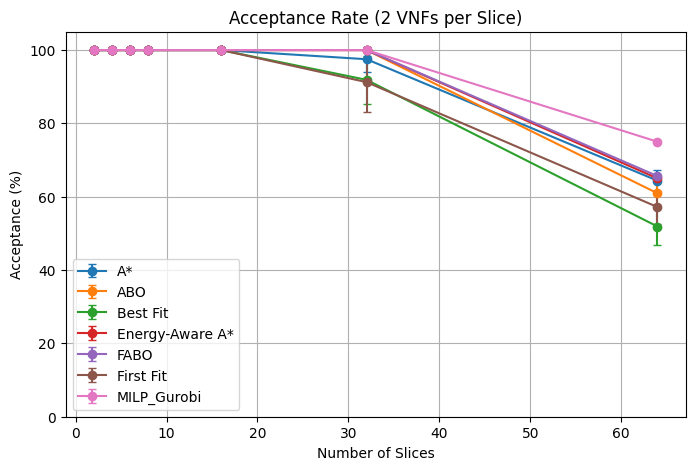

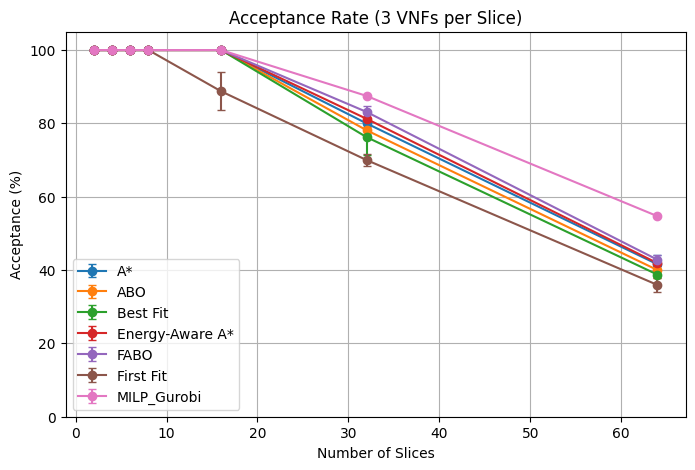

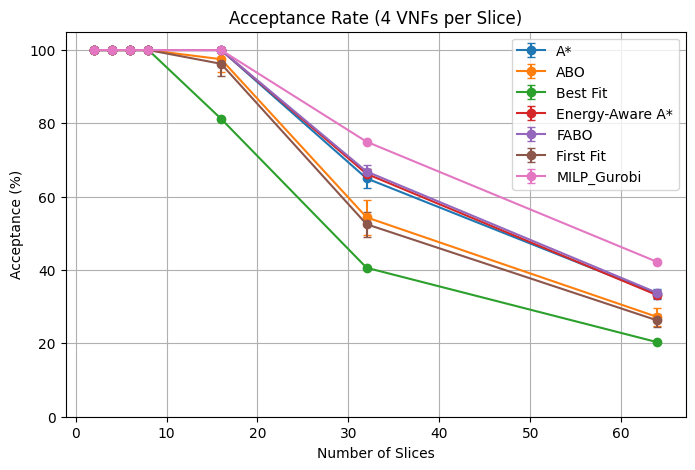

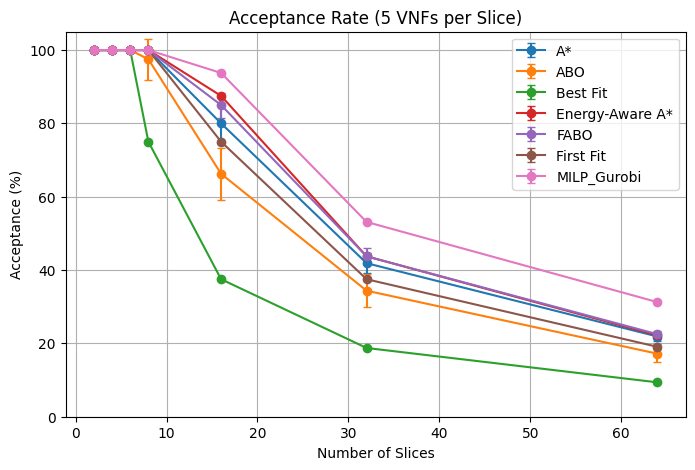

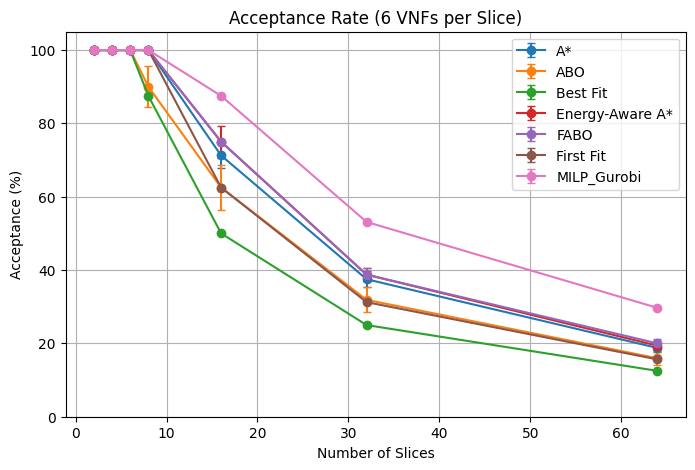

In [8]:
import matplotlib.pyplot as plt

for vnf in sorted(acceptance_agg["num_vnfs_per_slice"].unique()):

    sub = acceptance_agg[
        acceptance_agg["num_vnfs_per_slice"] == vnf
    ]

    plt.figure(figsize=(8,5))

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        plt.errorbar(
            m["num_slices"],
            m["mean_acceptance"],
            yerr=m["std_acceptance"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(f"Acceptance Rate ({vnf} VNFs per Slice)")
    plt.xlabel("Number of Slices")
    plt.ylabel("Acceptance (%)")
    plt.ylim(0, 105)
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
df_full = df[
    df["accepted"] == df["num_slices"]
].copy()

print(len(df_full))

800


In [10]:
energy_full_agg = (
    df_full.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
        num_runs=("total_energy", "count"),
    )
)

energy_full_agg.head()

,method,num_slices,num_vnfs_per_slice,mean_energy,std_energy,num_runs
0,A*,2,2,7.028125,0.548499,5
1,A*,2,3,11.050875,1.443416,5
2,A*,2,4,15.830625,1.020807,5
3,A*,2,5,20.281750,0.594122,5
4,A*,2,6,21.595500,0.803335,5


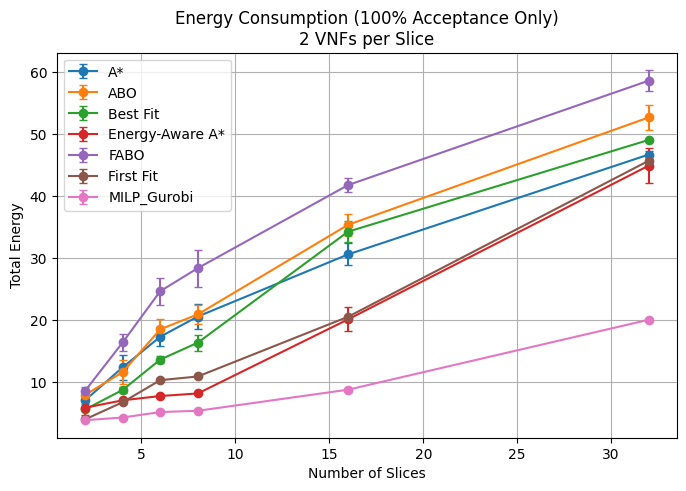

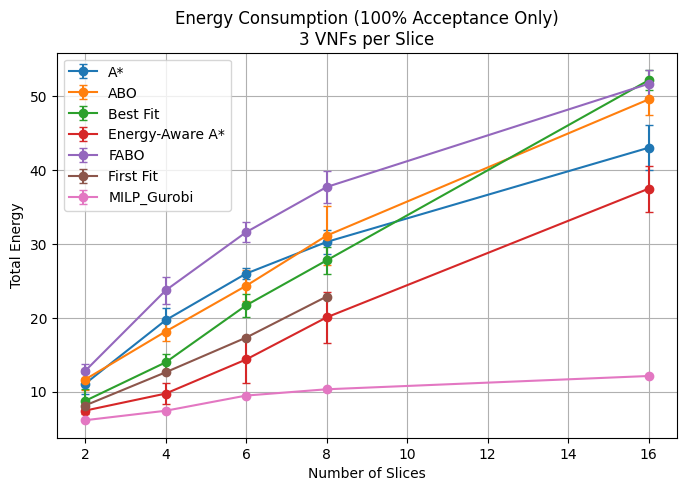

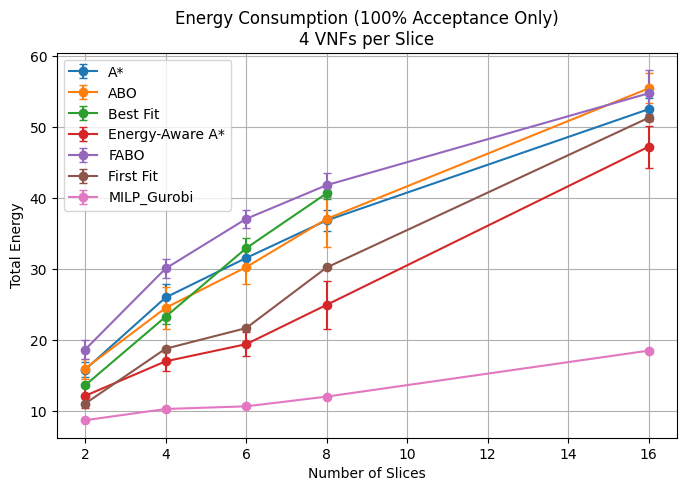

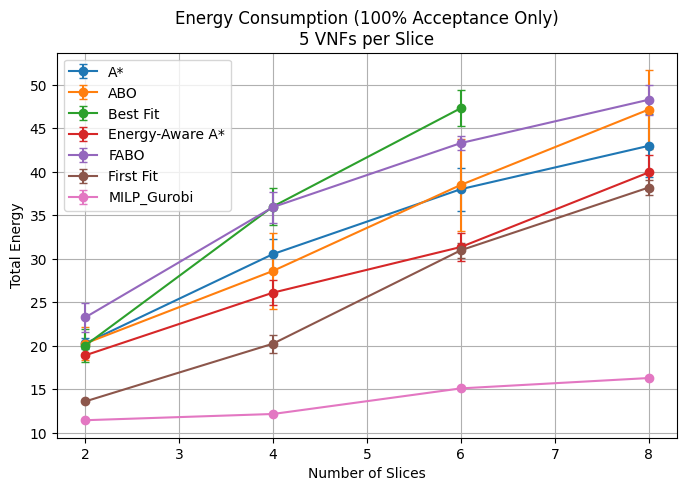

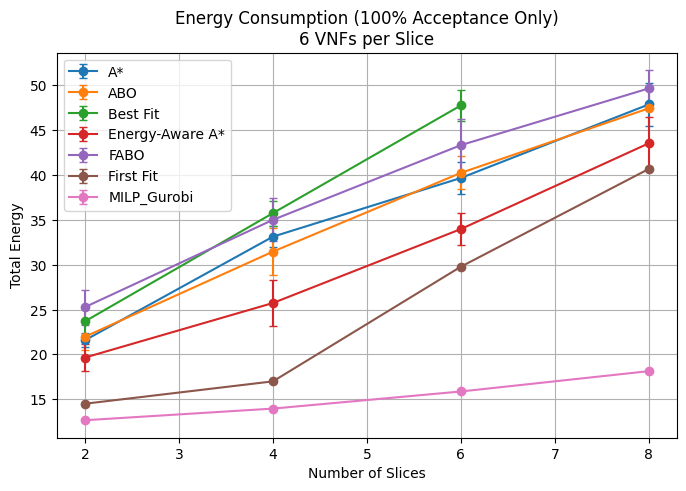

In [11]:
for vnf in sorted(energy_full_agg["num_vnfs_per_slice"].unique()):

    sub = energy_full_agg[
        energy_full_agg["num_vnfs_per_slice"] == vnf
    ]

    plt.figure(figsize=(8,5))

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        plt.errorbar(
            m["num_slices"],
            m["mean_energy"],
            yerr=m["std_energy"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(
        f"Energy Consumption (100% Acceptance Only)\n"
        f"{vnf} VNFs per Slice"
    )

    plt.xlabel("Number of Slices")
    plt.ylabel("Total Energy")
    plt.grid(True)
    plt.legend()
    plt.show()

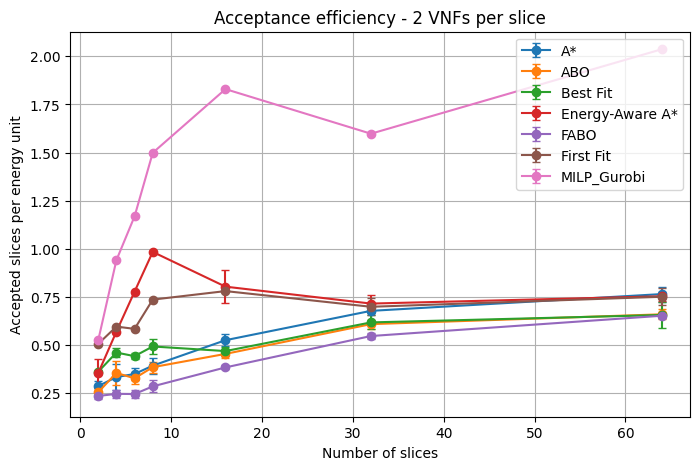

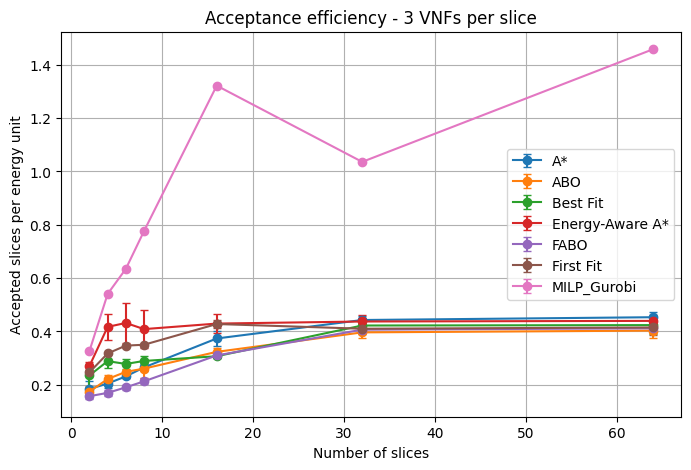

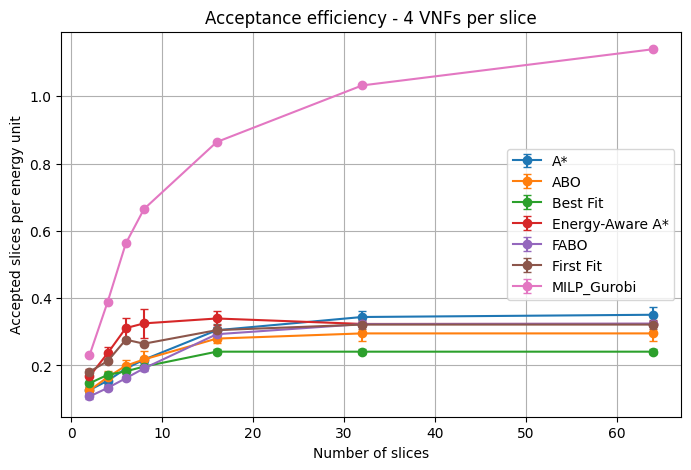

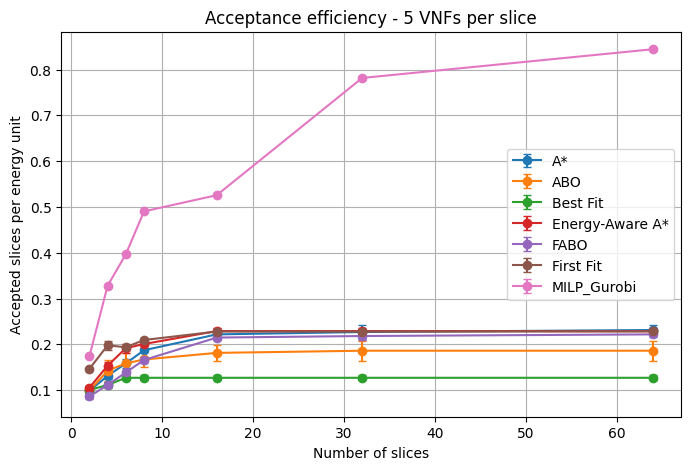

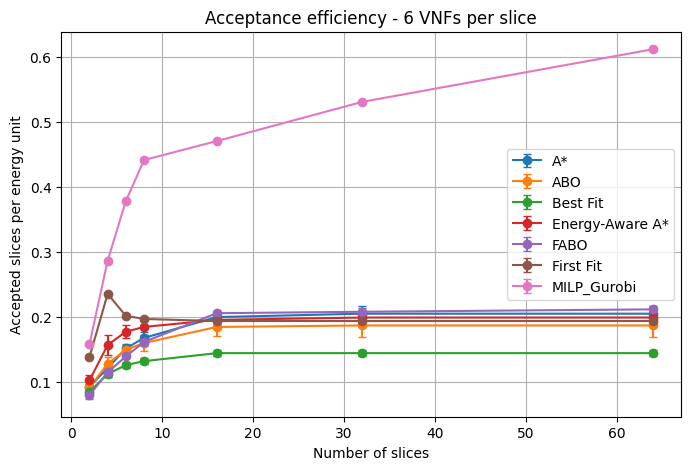

In [12]:
for vnf in sorted(metrics_agg["num_vnfs_per_slice"].unique()):
    sub = metrics_agg[metrics_agg["num_vnfs_per_slice"] == vnf]

    plt.figure(figsize=(8, 5))

    for method in sorted(sub["method"].unique()):
        m = sub[sub["method"] == method]
        plt.errorbar(
            m["num_slices"],
            m["mean_qos_efficiency"],
            yerr=m["std_qos_efficiency"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(f"Acceptance efficiency - {vnf} VNFs per slice")
    plt.xlabel("Number of slices")
    plt.ylabel("Accepted slices per energy unit")
    plt.grid(True)
    plt.legend()
    plt.show()